# Task Target Distributions

Two figures — one for all regression tasks, one for all classification tasks.

- **Regression**: mean, std, Q25/Q50/Q75 with 95% bootstrap CIs, one column per task.
- **Classification**: class proportion bars with 95% bootstrap CIs, one column per task.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name != "ocel-ocp":
    ROOT = next(p for p in [ROOT, *ROOT.parents] if p.name == "ocel-ocp")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from relbench.base import TaskType
from relbench.tasks import get_task

from data.dataset import register_all_datasets
from task import register_tasks, TASK_SPECS

register_all_datasets()
register_tasks()

%matplotlib inline
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

SPLITS = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#4c78a8", "val": "#f58518", "test": "#e45756"}
N_BOOTSTRAP = 2000
CI_ALPHA = 0.95

REGRESSION_TYPES = {TaskType.REGRESSION}
CLASSIFICATION_TYPES = {TaskType.BINARY_CLASSIFICATION, TaskType.MULTICLASS_CLASSIFICATION}

print(f"Registered {len(TASK_SPECS)} tasks")

100%|██████████| 22/22 [00:00<00:00, 84423.32it/s]

Registered 22 tasks


In [2]:
from tqdm.auto import tqdm

def bootstrap_ci(values: np.ndarray, stat_fn, n: int = 500, alpha: float = CI_ALPHA,
                 max_subsample: int = 10_000):
    """Percentile bootstrap CI. Subsamples large arrays to avoid OOM."""
    rng = np.random.default_rng(42)
    if len(values) > max_subsample:
        values = rng.choice(values, size=max_subsample, replace=False)
    point = stat_fn(values)
    boot = np.empty(n)
    for i in range(n):
        s = rng.choice(values, size=len(values), replace=True)
        boot[i] = stat_fn(s)
    lo = np.percentile(boot, (1 - alpha) / 2 * 100)
    hi = np.percentile(boot, (1 + alpha) / 2 * 100)
    return point, lo, hi


def load_targets(task, split: str) -> np.ndarray:
    return task.get_table(split, mask_input_cols=False).df[task.target_col].to_numpy(dtype=float)


def load_all_tasks():
    regression, classification = [], []
    for dataset_name, task_name, task_cls in tqdm(TASK_SPECS, desc="Loading tasks"):
        if task_cls.task_type not in REGRESSION_TYPES | CLASSIFICATION_TYPES:
            continue
        try:
            task = get_task(dataset_name, task_name, download=False)
        except Exception as e:
            print(f"[SKIP] {dataset_name}/{task_name}: {e}")
            continue
        entry = (dataset_name, task_name, task)
        if task_cls.task_type in REGRESSION_TYPES:
            regression.append(entry)
        else:
            classification.append(entry)
    return regression, classification


regression_tasks, classification_tasks = load_all_tasks()
print(f"Regression: {len(regression_tasks)}  Classification: {len(classification_tasks)}")

Loading tasks: 100%|██████████| 22/22 [00:00<00:00, 52191.57it/s]

Regression: 9  Classification: 13


## Regression tasks

Each column is one task. Rows: mean, std, quantiles (Q25/Q50/Q75). Error bars are 95% bootstrap CIs.

Regression tasks:  22%|██▏       | 2/9 [00:01<00:03,  1.80it/s]

Making task table for val split from scratch...
Loading Database object from /workspace/.cache/bpi2019/db...
Done in 9.84 seconds.
Loading Database object from /workspace/.cache/bpi2019/db...
Done in 10.10 seconds.
Done in 27.83 seconds.


Making task table for test split from scratch...
Loading Database object from /workspace/.cache/bpi2019/db...
Done in 10.27 seconds.
Done in 20.59 seconds.


Regression tasks: 100%|██████████| 9/9 [00:52<00:00,  5.88s/it]


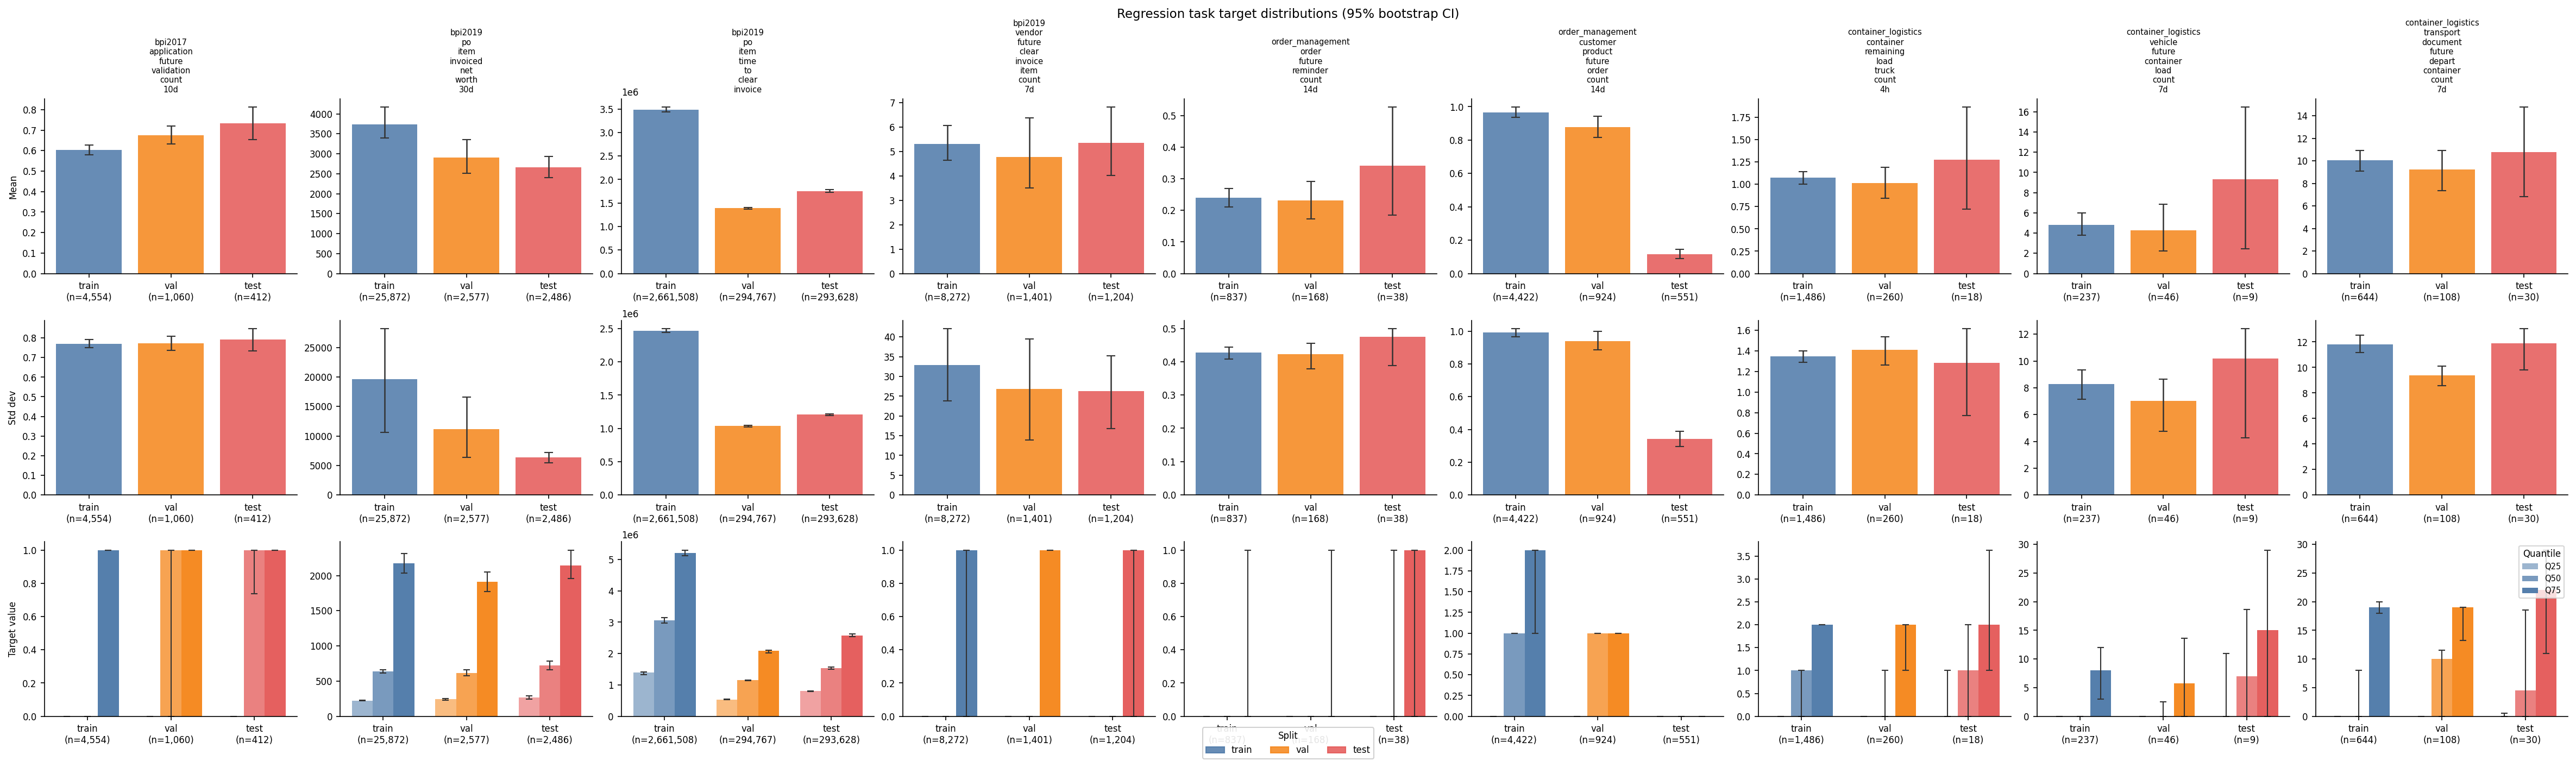

In [3]:
N_REG = len(regression_tasks)
fig, axes = plt.subplots(3, N_REG, figsize=(3.5 * N_REG, 9), constrained_layout=True)
if N_REG == 1:
    axes = axes[:, np.newaxis]

for col, (dataset_name, task_name, task) in enumerate(tqdm(regression_tasks, desc="Regression tasks")):
    split_stats = {}
    for split in tqdm(SPLITS, desc=task_name, leave=False):
        vals = load_targets(task, split)
        split_stats[split] = {
            "mean": bootstrap_ci(vals, np.mean),
            "std":  bootstrap_ci(vals, np.std),
            "q25":  bootstrap_ci(vals, lambda x: np.percentile(x, 25)),
            "q50":  bootstrap_ci(vals, lambda x: np.percentile(x, 50)),
            "q75":  bootstrap_ci(vals, lambda x: np.percentile(x, 75)),
            "n":    len(vals),
        }

    xs = np.arange(len(SPLITS))
    xlabels = [f"{s}\n(n={split_stats[s]['n']:,})" for s in SPLITS]
    colors = [SPLIT_COLORS[s] for s in SPLITS]
    short_name = task_name.replace("_", "\n")
    title = f"{dataset_name}\n{short_name}"

    # --- row 0: mean ---
    ax = axes[0, col]
    pts = [split_stats[s]["mean"][0] for s in SPLITS]
    los = [split_stats[s]["mean"][1] for s in SPLITS]
    his = [split_stats[s]["mean"][2] for s in SPLITS]
    ax.bar(xs, pts, color=colors, alpha=0.85)
    ax.errorbar(xs, pts, yerr=[np.array(pts)-np.array(los), np.array(his)-np.array(pts)],
                fmt="none", color="#333", capsize=4, linewidth=1.2)
    ax.set_xticks(xs); ax.set_xticklabels(xlabels)
    ax.set_title(title, fontsize=7)
    if col == 0: ax.set_ylabel("Mean")

    # --- row 1: std ---
    ax = axes[1, col]
    pts = [split_stats[s]["std"][0] for s in SPLITS]
    los = [split_stats[s]["std"][1] for s in SPLITS]
    his = [split_stats[s]["std"][2] for s in SPLITS]
    ax.bar(xs, pts, color=colors, alpha=0.85)
    ax.errorbar(xs, pts, yerr=[np.array(pts)-np.array(los), np.array(his)-np.array(pts)],
                fmt="none", color="#333", capsize=4, linewidth=1.2)
    ax.set_xticks(xs); ax.set_xticklabels(xlabels)
    if col == 0: ax.set_ylabel("Std dev")

    # --- row 2: quantiles ---
    ax = axes[2, col]
    width = 0.25
    for i, (qkey, qlabel, shade) in enumerate([("q25", "Q25", 0.55), ("q50", "Q50", 0.75), ("q75", "Q75", 0.95)]):
        offsets = xs + (i - 1) * width
        pts = [split_stats[s][qkey][0] for s in SPLITS]
        los = [split_stats[s][qkey][1] for s in SPLITS]
        his = [split_stats[s][qkey][2] for s in SPLITS]
        ax.bar(offsets, pts, width=width, color=colors, alpha=shade, label=qlabel)
        ax.errorbar(offsets, pts, yerr=[np.array(pts)-np.array(los), np.array(his)-np.array(pts)],
                    fmt="none", color="#333", capsize=3, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(xlabels)
    if col == 0: ax.set_ylabel("Target value")
    if col == N_REG - 1: ax.legend(title="Quantile", fontsize=7, loc="upper right")

handles = [plt.Rectangle((0,0),1,1, color=SPLIT_COLORS[s], alpha=0.85) for s in SPLITS]
fig.legend(handles, SPLITS, title="Split", loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.02), framealpha=0.9)
fig.suptitle("Regression task target distributions (95% bootstrap CI)", fontsize=11, y=1.01)
plt.show()

## Classification tasks

Each column is one task. Bars show the proportion of each class per split. Error bars are 95% bootstrap CIs.

Classification tasks:   0%|          | 0/13 [00:00<?, ?it/s]


ValueError: setting an array element with a sequence.

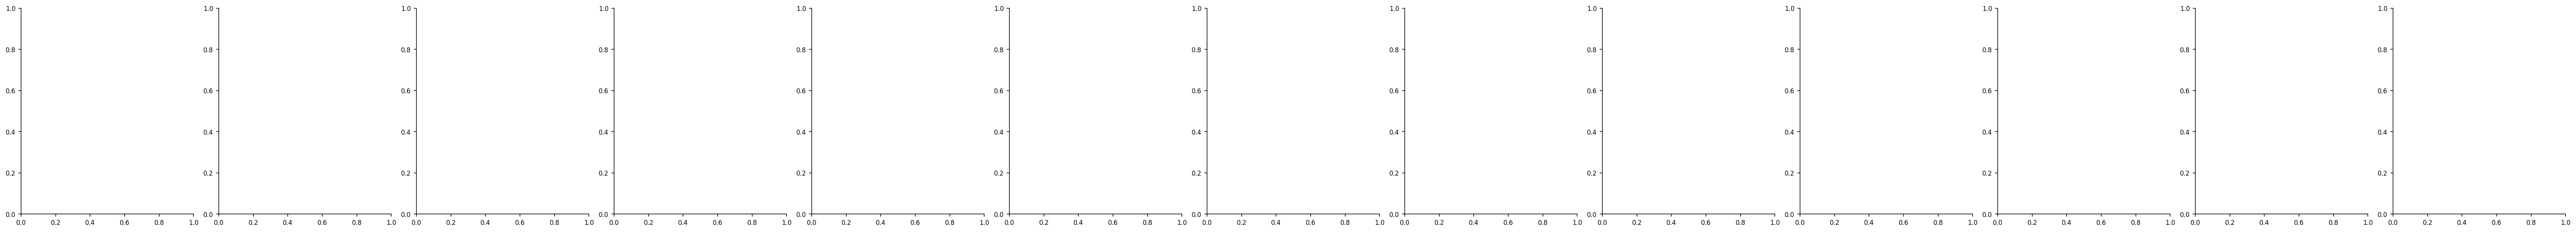

In [4]:
N_CLF = len(classification_tasks)
fig, axes = plt.subplots(1, N_CLF, figsize=(3.5 * N_CLF, 4), constrained_layout=True)
if N_CLF == 1:
    axes = [axes]

for col, (dataset_name, task_name, task) in enumerate(tqdm(classification_tasks, desc="Classification tasks")):
    ax = axes[col]

    all_classes = sorted(set(
        int(v)
        for split in SPLITS
        for v in load_targets(task, split)
        if not np.isnan(v)
    ))
    max_class = max(all_classes)

    split_stats = {}
    for split in tqdm(SPLITS, desc=task_name, leave=False):
        vals = load_targets(task, split).astype(int)
        n = len(vals)
        def class_fracs(v, classes=all_classes, mc=max_class, total=n):
            counts = np.bincount(v, minlength=mc + 1)
            return np.array([counts[c] / total for c in classes])
        pt, lo, hi = bootstrap_ci(vals, class_fracs)
        split_stats[split] = {"pt": pt, "lo": lo, "hi": hi, "n": n}

    xs = np.arange(len(all_classes))
    width = 0.8 / len(SPLITS)
    for si, split in enumerate(SPLITS):
        offsets = xs + (si - (len(SPLITS) - 1) / 2) * width
        pts = split_stats[split]["pt"]
        los = split_stats[split]["lo"]
        his = split_stats[split]["hi"]
        ax.bar(offsets, pts, width=width, color=SPLIT_COLORS[split], alpha=0.85,
               label=f"{split} (n={split_stats[split]['n']:,})")
        ax.errorbar(offsets, pts, yerr=[pts - los, his - pts],
                    fmt="none", color="#333", capsize=3, linewidth=1.0)

    ax.set_xticks(xs)
    ax.set_xticklabels([f"class {c}" for c in all_classes])
    ax.set_ylim(0, None)
    short_name = task_name.replace("_", "\n")
    ax.set_title(f"{dataset_name}\n{short_name}", fontsize=7)
    if col == 0:
        ax.set_ylabel("Proportion")

handles = [plt.Rectangle((0,0),1,1, color=SPLIT_COLORS[s], alpha=0.85) for s in SPLITS]
fig.legend(handles, SPLITS, title="Split", loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle("Classification task target distributions (95% bootstrap CI)", fontsize=11, y=1.01)
plt.show()